## Importing needed libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nltk.corpus import stopwords
from wordcloud import STOPWORDS
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict
from collections import  Counter
plt.style.use('ggplot')
stop=set(stopwords.words('english'))
import re
from nltk.tokenize import word_tokenize
import gensim
import string
import gc
import operator
import nltk

from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tqdm import tqdm
from keras.models import Sequential
from keras.layers import Embedding,LSTM,Dense,SpatialDropout1D
from keras.initializers import Constant
from sklearn.model_selection import train_test_split
from keras.optimizers import Adam
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.layers import Dense, Input, Dropout, GlobalAveragePooling1D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import precision_score, recall_score, f1_score

## Importing the dataset

In [2]:
train = pd.read_csv("../input/nlp-getting-started/train.csv")
test = pd.read_csv("../input/nlp-getting-started/test.csv")

In [3]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
test.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [5]:
train.size

38065

In [6]:
test.size

13052

# EDA

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='target', ylabel='count'>

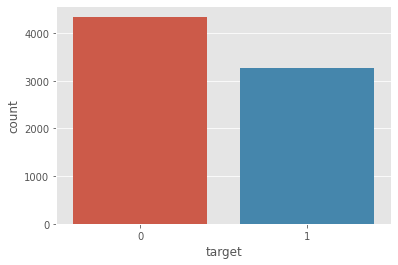

In [7]:
sns.countplot(train['target'])

## There are more tweets with target 0 (No disaster) than of Target 1( Disaster)

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


The number of null values in keyword are 61


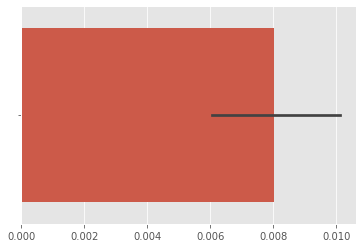

In [8]:
sns.barplot(train['keyword'].isnull().values)
print("The number of null values in keyword are", train['keyword'].isnull().sum())

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


The number of null values in location are 2533


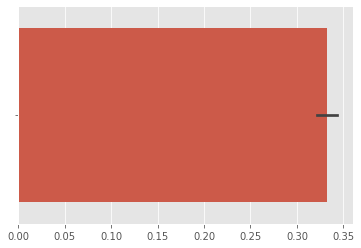

In [9]:
sns.barplot(train['location'].isnull().values)
print("The number of null values in location are", train['location'].isnull().sum())

## So, around 8% of keyword values and 33% of Location values are null in train sample

The number of null values in keyword are 26


/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


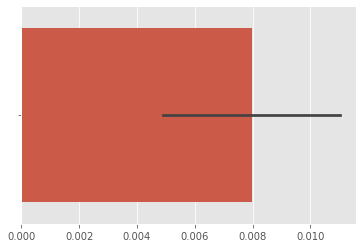

In [10]:
sns.barplot(test['keyword'].isnull().values)
print("The number of null values in keyword are", test['keyword'].isnull().sum())

The number of null values in keyword are 1105


/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


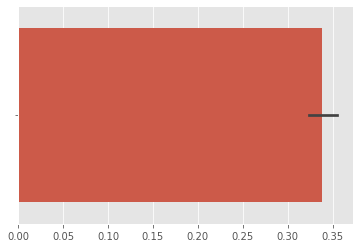

In [11]:
sns.barplot(test['location'].isnull().values)
print("The number of null values in keyword are", test['location'].isnull().sum())

## So, both training and test set have same ratio of missing values in keyword and location

## Filling the null values with "Unknown" for EDA purpose

In [12]:
for df in [train, test]:
    for col in ['keyword', 'location']:
        df[col] = df[col].fillna('Unknown')
train.head()

,id,keyword,location,text,target
0,1,Unknown,Unknown,Our Deeds are the Reason of this #earthquake M...,1
1,4,Unknown,Unknown,Forest fire near La Ronge Sask. Canada,1
2,5,Unknown,Unknown,All residents asked to 'shelter in place' are ...,1
3,6,Unknown,Unknown,"13,000 people receive #wildfires evacuation or...",1
4,7,Unknown,Unknown,Just got sent this photo from Ruby #Alaska as ...,1


In [13]:
train['keyword'].nunique()

222

## Top keywords that suggest a disaster tweet

In [14]:
ag = train.groupby('keyword').agg({'text':np.size, 'target':np.mean}).rename(columns={'text':'Count', 'target':'Disaster Probability'})
ag.sort_values('Disaster Probability', ascending=False).head(20)

,Count,Disaster Probability
keyword,,
wreckage,39,1.000000
debris,37,1.000000
derailment,39,1.000000
outbreak,40,0.975000
oil%20spill,38,0.973684
typhoon,38,0.973684
suicide%20bombing,33,0.969697
suicide%20bomber,31,0.967742
bombing,29,0.931034


## Top keywords that suggest not being a disaster tweet

In [15]:
ag = train.groupby('keyword').agg({'text':np.size, 'target':np.mean}).rename(columns={'text':'Count', 'target':'Disaster Probability'})
ag.sort_values('Disaster Probability', ascending=True).head(20)

,Count,Disaster Probability
keyword,,
aftershock,34,0.000000
body%20bags,41,0.024390
ruin,37,0.027027
blazing,34,0.029412
body%20bag,33,0.030303
electrocute,32,0.031250
screaming,36,0.055556
traumatised,35,0.057143
panicking,33,0.060606


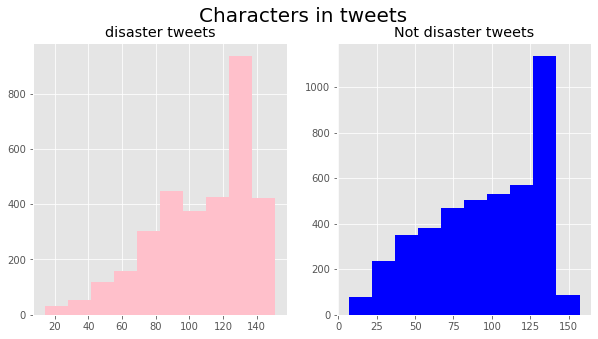

In [16]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
tweet_len1=train[train['target']==1]['text'].str.len()
ax1.hist(tweet_len1,color='pink')
ax1.set_title('disaster tweets')
tweet_len2=train[train['target']==0]['text'].str.len()
ax2.hist(tweet_len2,color='blue')
ax2.set_title('Not disaster tweets')
fig.suptitle('Characters in tweets', size=20)
plt.show()

## The character distribution is almost same for both

Text(0.5, 1.0, 'Stop words distribution in Training, Test Set')

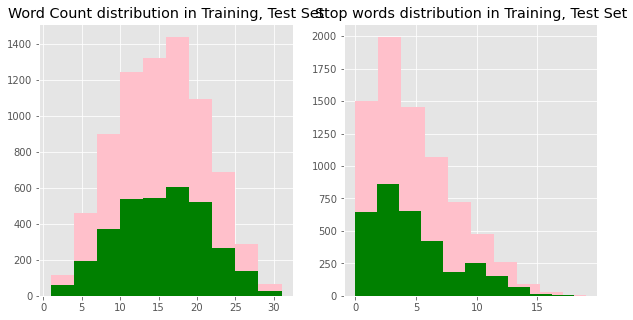

In [17]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
ax1.hist(train['text'].apply(lambda x: len(str(x).split())), color='pink')
ax1.hist(test['text'].apply(lambda x: len(str(x).split())), color='green')
ax1.set_title('Word Count distribution in Training, Test Set')
ax2.hist(train['text'].apply(lambda x: len([w for w in str(x).lower().split() if w in STOPWORDS])), color='pink')
ax2.hist(test['text'].apply(lambda x: len([w for w in str(x).lower().split() if w in STOPWORDS])),color='green')
ax2.set_title('Stop words distribution in Training, Test Set')

## Emojis convey a lot, so we will replace them with words

In [18]:
!pip install emot

In [19]:
from emot.emo_unicode import UNICODE_EMO, EMOTICONS
# Function for converting emojis into word
def convert_emojis(text):
    for emot in UNICODE_EMO:
        text = text.replace(emot, "_".join(UNICODE_EMO[emot].replace(",","").replace(":","").split()))
    return text

train['text'] = train['text'].apply(lambda x: convert_emojis(x))
test['text'] = test['text'].apply(lambda x: convert_emojis(x))

## URL, Mention etc. play no significant rule in the sentiment of tweet, so we will remove them 

In [20]:
from nltk.corpus import stopwords
# load stop words
stop_word = stopwords.words('english')

def clean(text):
    #     remove urls
    text = re.sub(r'http\S+', " ", text)
    #     remove mentions
    text = re.sub(r'@\w+',' ',text)
    #     remove hastags
    text = re.sub(r'#\w+', ' ', text)
    #     remove digits
    text = re.sub(r'\d+', ' ', text)
    #     remove html tags
    text = re.sub('r<.*?>',' ', text) 
    #     remove stop words 
    text = text.split()
    text = " ".join([word for word in text if not word in stop_word])
        
    return text

In [21]:
train['text'] = train['text'].apply(lambda x: clean(x))
test['text'] = test['text'].apply(lambda x: clean(x))

In [22]:
train.head()

,id,keyword,location,text,target
0,1,Unknown,Unknown,Our Deeds Reason May ALLAH Forgive us,1
1,4,Unknown,Unknown,Forest fire near La Ronge Sask. Canada,1
2,5,Unknown,Unknown,All residents asked 'shelter place' notified o...,1
3,6,Unknown,Unknown,", people receive evacuation orders California",1
4,7,Unknown,Unknown,Just got sent photo Ruby smoke pours school,1


## Word Embedding using Glove

In [23]:
from tqdm import tqdm
def create_corpus(train):
    corpus=[]
    for tweet in tqdm(train['text']):
        words=[word.lower() for word in word_tokenize(tweet) if((word.isalpha()==1) & (word not in stop))]
        corpus.append(words)
    return corpus
        

In [24]:
corpus=create_corpus(train)

100%|██████████| 7613/7613 [00:01<00:00, 4154.33it/s]


In [25]:
embedding_dict={}
with open('../input/glove6b/glove.6B.100d.txt','r', encoding='utf8') as f:
    for line in f:
        values=line.split()
        word=values[0]
        vectors=np.asarray(values[1:],'float32')
        embedding_dict[word]=vectors
f.close()

In [26]:
MAX_LEN=50
tokenizer_obj=Tokenizer()
tokenizer_obj.fit_on_texts(corpus)
sequences=tokenizer_obj.texts_to_sequences(corpus)

tweet_pad=pad_sequences(sequences,maxlen=MAX_LEN,truncating='post',padding='post')

In [27]:
word_index=tokenizer_obj.word_index
print('Number of unique words:',len(word_index))

Number of unique words: 12484


In [28]:
num_words=len(word_index)+1
embedding_matrix=np.zeros((num_words,100))

for word,i in tqdm(word_index.items()):
    if i > num_words:
        continue
    
    emb_vec=embedding_dict.get(word)
    if emb_vec is not None:
        embedding_matrix[i]=emb_vec

100%|██████████| 12484/12484 [00:00<00:00, 308398.17it/s]


## Basic LSTM model

In [29]:
model=Sequential()

embedding=Embedding(num_words,100,embeddings_initializer=Constant(embedding_matrix),
                   input_length=MAX_LEN,trainable=False)

model.add(embedding)
model.add(SpatialDropout1D(0.2))
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))


optimzer=Adam(learning_rate=1e-5)

model.compile(loss='binary_crossentropy',optimizer=optimzer,metrics=['accuracy'])

In [30]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 50, 100)           1248500   
_________________________________________________________________
spatial_dropout1d (SpatialDr (None, 50, 100)           0         
_________________________________________________________________
lstm (LSTM)                  (None, 64)                42240     
_________________________________________________________________
dense (Dense)                (None, 1)                 65        
Total params: 1,290,805
Trainable params: 42,305
Non-trainable params: 1,248,500
_________________________________________________________________


In [31]:
train1=tweet_pad[:train.shape[0]]

In [32]:
X_train,X_test,y_train,y_test=train_test_split(train1,train['target'].values,test_size=0.2)
print('Shape of train',X_train.shape)
print("Shape of Validation ",X_test.shape)

Shape of train (6090, 50)
Shape of Validation  (1523, 50)


In [33]:
history=model.fit(X_train,y_train,batch_size=4,epochs=15,validation_data=(X_test,y_test),verbose=2)

Epoch 1/15
1523/1523 - 65s - loss: 0.6912 - accuracy: 0.5693 - val_loss: 0.6867 - val_accuracy: 0.5666
Epoch 2/15
1523/1523 - 61s - loss: 0.5884 - accuracy: 0.7092 - val_loss: 0.5481 - val_accuracy: 0.7472
Epoch 3/15
1523/1523 - 62s - loss: 0.5387 - accuracy: 0.7473 - val_loss: 0.5342 - val_accuracy: 0.7551
Epoch 4/15
1523/1523 - 61s - loss: 0.5291 - accuracy: 0.7530 - val_loss: 0.5272 - val_accuracy: 0.7557
Epoch 5/15
1523/1523 - 62s - loss: 0.5195 - accuracy: 0.7616 - val_loss: 0.5226 - val_accuracy: 0.7590
Epoch 6/15
1523/1523 - 62s - loss: 0.5150 - accuracy: 0.7640 - val_loss: 0.5181 - val_accuracy: 0.7623
Epoch 7/15
1523/1523 - 61s - loss: 0.5060 - accuracy: 0.7716 - val_loss: 0.5159 - val_accuracy: 0.7669
Epoch 8/15
1523/1523 - 62s - loss: 0.4977 - accuracy: 0.7729 - val_loss: 0.5126 - val_accuracy: 0.7689
Epoch 9/15
1523/1523 - 73s - loss: 0.4973 - accuracy: 0.7787 - val_loss: 0.5096 - val_accuracy: 0.7708
Epoch 10/15
1523/1523 - 73s - loss: 0.4906 - accuracy: 0.7791 - val_loss:

## If you want to score even more, change all the tweets that has keywords wreckage, debris, derailment to 1 as we saw above in EDA that they have almost 100% chance of being disaster tweet. Similarly, check for Non Disaster tweets

## Upvote if you found it helpful!